# Speed–Unit Correlation Analysis

For every **good** and **MUA** unit we compute the Pearson correlation between the
unit's continuous firing rate and the mouse's movement speed over the full session.

Pipeline:
1. Load session data (same as `direct_path_analysis.ipynb`).
2. Compute a session-wide speed trace from `summary_df` coordinate tracking.
3. For each unit, build a continuous firing-rate trace (Gaussian-smoothed spike histogram).
4. Compute Pearson r; plot the distribution to choose a threshold.
5. For units above threshold: plot speed + firing rate over a random session window.
6. For units above threshold: find and plot the best-correlated time segments via rolling correlation.

In [ ]:
import scipy.io
import pandas as pd
import numpy as np
import pickle
import random
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

# Import speed_analysis directly from its file path — this avoids going through
# navigraph/analysis/__init__.py, which triggers navigraph/core/__init__.py →
# experiment_runner → omegaconf (not installed in this environment).
import importlib.util as _ilu
_sa_path = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/navigraph/analysis/speed_analysis.py')
_spec = _ilu.spec_from_file_location('speed_analysis', _sa_path)
_mod  = _ilu.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
compute_path_speed = _mod.compute_path_speed

In [ ]:
FPS  = 40        # video frame rate (Hz)
FS   = 30_000    # Neuropixels sampling rate (Hz)
MAZE_START = 30
MAZE_END   = 767

# Firing-rate smoothing kernel width (seconds)
RATE_SMOOTH_SIGMA_S = 0.5

# Speed smoothing (frames) — same default as speed_analysis.py
SPEED_SMOOTH_FRAMES = 5

## Session setup

In [ ]:
session = '10/09/2025'

YY   = session[-2:]
YYYY = session[-4:]
MM   = session[3:5]
DD   = session[:2]

DD_MM_YYYY = f"{DD}_{MM}_{YYYY}"
MM_DD_YYYY = f"{MM}_{DD}_{YYYY}"

In [ ]:
spike_clusters = scipy.io.loadmat(
    rf'/var/home/almogmeir/Documents/M.Sc/Project/SpikesData/{DD_MM_YYYY}/aligned_spike_clusters.mat')
spike_times = scipy.io.loadmat(
    rf'/var/home/almogmeir/Documents/M.Sc/Project/SpikesData/{DD_MM_YYYY}/aligned_spike_times.mat')
cluster_info = pd.read_csv(
    rf'/var/home/almogmeir/Documents/M.Sc/Project/SpikesData/{DD_MM_YYYY}/cluster_info.tsv', sep='\t')

In [ ]:
summary_df_pkl = (
    f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/"
    f"resources/outputs/{DD_MM_YYYY}/summary_df.pkl"
)
with open(summary_df_pkl, 'rb') as f:
    summary_df = pickle.load(f)

print(f"summary_df shape: {summary_df.shape}")

## Spike data

In [ ]:
good_units = cluster_info[cluster_info['group'] == 'good'].copy().reset_index(drop=True)
mua_units  = cluster_info[cluster_info['group'] == 'mua' ].copy().reset_index(drop=True)

print(f"Good units : {len(good_units)}")
print(f"MUA  units : {len(mua_units)}")

In [ ]:
def _unwrap_mat(d):
    keys = [k for k in d if not k.startswith('__')]
    return d[keys[0]].flatten()

spike_times_all    = _unwrap_mat(spike_times)
spike_clusters_all = _unwrap_mat(spike_clusters)

maze_spike_times    = spike_times_all[MAZE_START:MAZE_END]
maze_spike_clusters = spike_clusters_all[MAZE_START:MAZE_END]

assert len(maze_spike_times) == 737, f"Expected 737 maze trials, got {len(maze_spike_times)}"
print(f"Maze trials: {len(maze_spike_times)}")

In [ ]:
# Flatten MultiIndex columns for groupby/metadata extraction
sdf = summary_df.copy()
sdf.columns = [
    '_'.join([c for c in col if c]) if isinstance(col, tuple) else col
    for col in sdf.columns
]

trial_meta = sdf.groupby('trial_idx').agg(
    start_frame=('frame_idx_global', 'min'),
    trial_length=('trial_length', 'first'),
)
trial_meta['start_abs'] = trial_meta['start_frame'] / FPS
trial_meta['end_abs']   = trial_meta['start_abs'] + trial_meta['trial_length']

print(f"Trials in session: {len(trial_meta)}")
print(f"Session span: {trial_meta['start_abs'].min():.1f}s – {trial_meta['end_abs'].max():.1f}s")

## Session-wide speed trace

In [ ]:
session_start_frame = int(sdf['frame_idx_global'].min())
session_end_frame   = int(sdf['frame_idx_global'].max())

print(f"Frame range: {session_start_frame} – {session_end_frame}  "
      f"({(session_end_frame - session_start_frame) / FPS:.1f} s)")

# summary_df has MultiIndex columns ('headstage', 'x') etc — pass as tuples
times_speed_rel, speed_global, _ = compute_path_speed(
    summary_df,
    session_start_frame,
    session_end_frame,
    x_col=('headstage', 'x'),
    y_col=('headstage', 'y'),
    frame_col='frame_idx_global',
    smooth_window_frames=SPEED_SMOOTH_FRAMES,
)

# Convert relative time to absolute seconds
t_speed_abs = times_speed_rel + session_start_frame / FPS

print(f"Speed samples: {len(speed_global)}  "
      f"(NaN: {np.isnan(speed_global).sum()})")

fig, ax = plt.subplots(figsize=(14, 2.5))
ax.plot(t_speed_abs, speed_global, linewidth=0.5, color='steelblue')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Speed (px/s)')
ax.set_title('Mouse speed — full session')
plt.tight_layout()
plt.show()

## Firing-rate helpers

In [ ]:
def get_all_spikes_abs(cluster_id):
    """All spike times (absolute seconds) for one unit across all maze trials."""
    chunks = []
    for t in trial_meta.index:
        st = np.asarray(maze_spike_times[t]).flatten() / FS
        sc = np.asarray(maze_spike_clusters[t]).flatten()
        t_abs = trial_meta.loc[t, 'start_abs'] + st
        chunks.append(t_abs[sc == cluster_id])
    return np.concatenate(chunks) if chunks else np.array([])


def compute_rate_on_axis(spike_times_abs, t_axis, sigma_s=RATE_SMOOTH_SIGMA_S):
    """Gaussian-smoothed firing rate (Hz) evaluated at the same time points as t_axis."""
    if len(t_axis) < 2:
        return np.zeros(len(t_axis))
    dt = np.median(np.diff(t_axis))
    # Bin edges centred on each sample
    edges = np.concatenate([
        [t_axis[0] - dt / 2],
        (t_axis[:-1] + t_axis[1:]) / 2,
        [t_axis[-1] + dt / 2],
    ])
    counts, _ = np.histogram(spike_times_abs, bins=edges)
    rate = counts.astype(float) / dt
    if sigma_s > 0:
        rate = gaussian_filter1d(rate, sigma=sigma_s / dt)
    return rate

## Compute correlations for all good + MUA units

We correlate over frames where speed is **not NaN** (tracking drop-outs are excluded).

In [ ]:
all_units = pd.concat([
    good_units[['cluster_id']].assign(group='good'),
    mua_units[['cluster_id']].assign(group='mua'),
], ignore_index=True)

valid_speed_mask = ~np.isnan(speed_global)
MIN_VALID_SAMPLES = 200

corr_results = []
for i, row in all_units.iterrows():
    cid = int(row['cluster_id'])
    grp = row['group']

    spikes = get_all_spikes_abs(cid)
    rate   = compute_rate_on_axis(spikes, t_speed_abs)

    mask = valid_speed_mask
    if mask.sum() < MIN_VALID_SAMPLES:
        corr_results.append({'cluster_id': cid, 'group': grp, 'r': np.nan, 'p': np.nan})
        continue

    r, p = pearsonr(speed_global[mask], rate[mask])
    corr_results.append({'cluster_id': cid, 'group': grp, 'r': r, 'p': p})

    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{len(all_units)} units done…")

corr_df = pd.DataFrame(corr_results).sort_values('r', ascending=False).reset_index(drop=True)
print(f"\nDone. {len(corr_df)} units.")
corr_df.head(20)

## Correlation distribution — choose threshold

In [ ]:
r_vals = corr_df['r'].dropna()

mu, sigma = r_vals.mean(), r_vals.std()
threshold_2sd = mu + 2 * sigma

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r_vals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(threshold_2sd, color='red',    linestyle='--', linewidth=1.5,
           label=f'mean+2σ = {threshold_2sd:.3f}')
ax.axvline(mu,            color='black',  linestyle=':',  linewidth=1.0,
           label=f'mean = {mu:.3f}')
ax.set_xlabel('Pearson r  (speed vs. firing rate)')
ax.set_ylabel('Unit count')
ax.set_title('Speed–unit correlation distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f"mean={mu:.3f}  σ={sigma:.3f}  mean+2σ={threshold_2sd:.3f}")
print(f"Units above threshold: {(r_vals > threshold_2sd).sum()}  "
      f"(good: {((corr_df['r'] > threshold_2sd) & (corr_df['group']=='good')).sum()}, "
      f"mua: {((corr_df['r'] > threshold_2sd) & (corr_df['group']=='mua')).sum()})")

In [ ]:
# Adjust if the auto threshold is too permissive / strict
CORR_THRESHOLD = threshold_2sd   # ← edit manually after inspecting histogram

high_corr = corr_df[corr_df['r'] > CORR_THRESHOLD].reset_index(drop=True)
print(f"Units above threshold ({CORR_THRESHOLD:.3f}): {len(high_corr)}")
display(high_corr)

## High-correlation units — random session window

A randomly chosen 60-second window shows speed and firing rate overlaid for each
unit above threshold.

In [ ]:
WINDOW_S    = 60.0
MAX_PANELS  = 10      # cap figure height

session_duration_s = t_speed_abs[-1] - t_speed_abs[0]
t_win_start = t_speed_abs[0] + random.uniform(0, max(0, session_duration_s - WINDOW_S))
t_win_end   = t_win_start + WINDOW_S

win_mask = (t_speed_abs >= t_win_start) & (t_speed_abs <= t_win_end)
t_win    = t_speed_abs[win_mask]
spd_win  = speed_global[win_mask]

units_to_plot = high_corr.head(MAX_PANELS)
n_panels = len(units_to_plot)
print(f"Plotting {n_panels} units, window {t_win_start:.1f}–{t_win_end:.1f} s")

if n_panels == 0:
    print("No units above threshold — lower CORR_THRESHOLD and re-run.")
else:
    fig, axes = plt.subplots(n_panels, 1,
                             figsize=(14, 2.8 * n_panels),
                             sharex=True)
    if n_panels == 1:
        axes = [axes]

    for ax, (_, urow) in zip(axes, units_to_plot.iterrows()):
        cid = int(urow['cluster_id'])
        spikes = get_all_spikes_abs(cid)
        rate_full = compute_rate_on_axis(spikes, t_speed_abs)
        rate_win  = rate_full[win_mask]

        ax2 = ax.twinx()
        ax.fill_between(t_win, spd_win, alpha=0.25, color='steelblue')
        ax.plot(t_win, spd_win, color='steelblue', linewidth=0.8)
        ax.set_ylabel('Speed (px/s)', color='steelblue', fontsize=8)
        ax.tick_params(axis='y', labelcolor='steelblue', labelsize=7)

        ax2.plot(t_win, rate_win, color='darkorange', linewidth=1.2)
        ax2.set_ylabel('Rate (Hz)', color='darkorange', fontsize=8)
        ax2.tick_params(axis='y', labelcolor='darkorange', labelsize=7)

        ax.set_title(
            f"Unit {cid} ({urow['group']})  r = {urow['r']:.3f}",
            fontsize=9, loc='left'
        )

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(
        f"Speed-correlated units — random {int(WINDOW_S)} s window  "
        f"[t = {t_win_start:.1f} s]",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

## Best-correlated time segments

A rolling Pearson r (window = `ROLLING_WINDOW_S` seconds, step = `ROLLING_STEP_S`
seconds) is computed for each top unit. The `TOP_SEGMENTS` non-overlapping windows
with the highest local r are extracted and plotted alongside the rolling-r trace.

In [ ]:
ROLLING_WINDOW_S = 30.0
ROLLING_STEP_S   = 5.0
TOP_SEGMENTS     = 3
MAX_UNITS_DETAIL = 5    # run detail plots for this many top units

dt_speed = float(np.median(np.diff(t_speed_abs)))
win_n    = max(2, int(round(ROLLING_WINDOW_S / dt_speed)))
step_n   = max(1, int(round(ROLLING_STEP_S   / dt_speed)))

# NaN-filled speed for rolling windows (use session median for gaps)
spd_filled = np.where(np.isnan(speed_global),
                      float(np.nanmedian(speed_global)),
                      speed_global)


def rolling_corr(rate_full):
    """Return (t_centers, r_values) for a sliding window over the session."""
    r_vals, t_cens = [], []
    for i in range(0, len(t_speed_abs) - win_n, step_n):
        s_seg = spd_filled[i:i + win_n]
        r_seg = rate_full[i:i + win_n]
        if np.std(s_seg) > 1e-9 and np.std(r_seg) > 1e-9:
            r_vals.append(np.corrcoef(s_seg, r_seg)[0, 1])
        else:
            r_vals.append(np.nan)
        t_cens.append(t_speed_abs[i + win_n // 2])
    return np.array(t_cens), np.array(r_vals)


def pick_top_segments(t_cens, r_vals, n=TOP_SEGMENTS):
    """Return center times of N non-overlapping windows with highest r."""
    order = np.argsort(np.where(np.isnan(r_vals), -np.inf, r_vals))[::-1]
    selected = []
    for idx in order:
        tc = t_cens[idx]
        if any(abs(tc - ts) < ROLLING_WINDOW_S for ts in selected):
            continue
        selected.append(tc)
        if len(selected) >= n:
            break
    return selected


units_detail = high_corr.head(MAX_UNITS_DETAIL)

for _, urow in units_detail.iterrows():
    cid = int(urow['cluster_id'])
    grp = urow['group']
    r_global = urow['r']

    spikes    = get_all_spikes_abs(cid)
    rate_full = compute_rate_on_axis(spikes, t_speed_abs)

    t_cens, r_roll = rolling_corr(rate_full)
    seg_centers     = pick_top_segments(t_cens, r_roll)

    n_segs = len(seg_centers)
    fig, axes = plt.subplots(1 + n_segs, 1,
                             figsize=(14, 3.2 * (1 + n_segs)))
    if 1 + n_segs == 1:
        axes = [axes]

    # --- rolling-r overview ---
    ax0 = axes[0]
    ax0.plot(t_cens, r_roll, color='purple', linewidth=0.9)
    ax0.axhline(0, color='black', linewidth=0.5, linestyle='--')
    for tc in seg_centers:
        ax0.axvspan(tc - ROLLING_WINDOW_S / 2, tc + ROLLING_WINDOW_S / 2,
                    alpha=0.18, color='limegreen')
    ax0.set_ylabel('Rolling Pearson r')
    ax0.set_title(
        f"Unit {cid} ({grp})  global r = {r_global:.3f}  "
        f"| rolling r ({int(ROLLING_WINDOW_S)} s window, {int(ROLLING_STEP_S)} s step)",
        fontsize=9
    )

    # --- per-segment detail ---
    for k, tc in enumerate(seg_centers):
        ax = axes[k + 1]
        t0 = tc - ROLLING_WINDOW_S / 2
        t1 = tc + ROLLING_WINDOW_S / 2
        seg_mask = (t_speed_abs >= t0) & (t_speed_abs <= t1)
        t_seg   = t_speed_abs[seg_mask]
        spd_seg = spd_filled[seg_mask]
        rt_seg  = rate_full[seg_mask]

        # local r from the rolling array
        closest = int(np.argmin(np.abs(t_cens - tc)))
        r_local = r_roll[closest]

        ax2 = ax.twinx()
        ax.fill_between(t_seg, spd_seg, alpha=0.25, color='steelblue')
        ax.plot(t_seg, spd_seg, color='steelblue', linewidth=0.9)
        ax.set_ylabel('Speed (px/s)', color='steelblue', fontsize=8)
        ax.tick_params(axis='y', labelcolor='steelblue', labelsize=7)

        ax2.plot(t_seg, rt_seg, color='darkorange', linewidth=1.2)
        ax2.set_ylabel('Rate (Hz)', color='darkorange', fontsize=8)
        ax2.tick_params(axis='y', labelcolor='darkorange', labelsize=7)

        ax.set_title(
            f"Segment {k + 1}  t = {tc:.1f} s  |  local r = {r_local:.3f}",
            fontsize=9, loc='left'
        )

    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

## Population-level analysis (PCA)

Build a **time × units** population rate matrix, z-score each unit, then run PCA.
For each PC we compute the Pearson correlation between the PC score trajectory and the
mouse speed.  PCs whose score co-varies with speed may reflect a movement-related
population signal even if no single unit clears the per-unit threshold.

In [26]:
# Build population rate matrix: shape (n_timepoints, n_units)
# Rows = video frames, columns = all good+mua units in the same order as all_units

n_time = len(t_speed_abs)
rate_matrix = np.zeros((n_time, len(all_units)), dtype=np.float32)

for i, (_, row) in enumerate(all_units.iterrows()):
    cid = int(row['cluster_id'])
    spikes = get_all_spikes_abs(cid)
    rate_matrix[:, i] = compute_rate_on_axis(spikes, t_speed_abs)
    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{len(all_units)} units done…", end='\r')

print(f"\nRate matrix shape: {rate_matrix.shape}  "
      f"(~{rate_matrix.nbytes / 1e6:.0f} MB)")

  170/171 units done…
Rate matrix shape: (144685, 171)  (~99 MB)


In [28]:
%pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 14.2 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


 pc         r    abs_r             p  var_exp
  2  0.122892 0.122892  0.000000e+00 0.118701
 15  0.084657 0.084657 2.625901e-228 0.008302
  1  0.079816 0.079816 4.278867e-203 0.223072
  4 -0.076220 0.076220 2.439871e-185 0.026631
  6  0.062747 0.062747 3.820156e-126 0.018878
  3 -0.049915 0.049915  1.766583e-80 0.086359
 20 -0.047421 0.047421  8.210042e-73 0.006054
 14 -0.045399 0.045399  6.944723e-67 0.008501
 19 -0.038632 0.038632  6.448768e-49 0.006234
  7  0.037496 0.037496  3.499234e-46 0.016456
 13  0.036277 0.036277  2.440537e-43 0.009356
 12  0.021527 0.021527  2.628915e-16 0.009700
  5 -0.017922 0.017922  9.253345e-12 0.023757
 17 -0.015599 0.015599  2.962684e-09 0.007285
 18  0.014106 0.014106  8.055526e-08 0.006632
  8 -0.013705 0.013705  1.855153e-07 0.014114
 10  0.011746 0.011746  7.894268e-06 0.011935
  9  0.008075 0.008075  2.128870e-03 0.012447
 11  0.001505 0.001505  5.670408e-01 0.010774
 16  0.000213 0.000213  9.354428e-01 0.007463


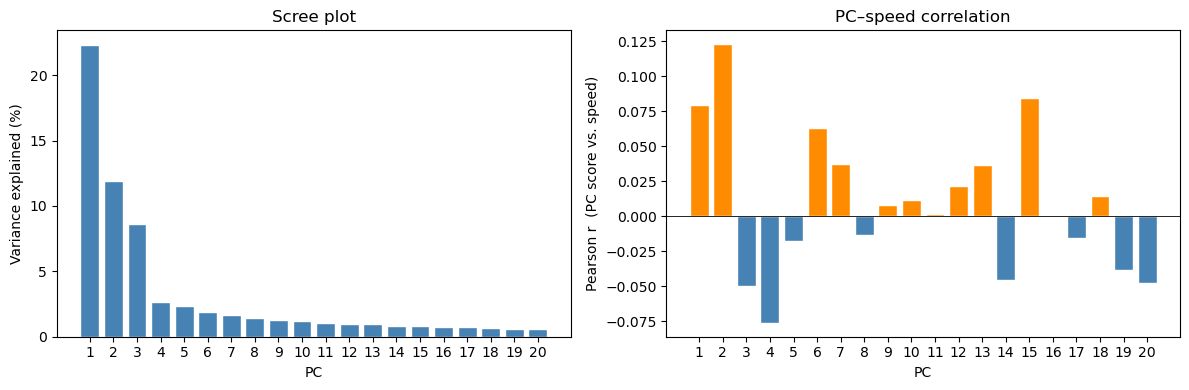

In [29]:
from sklearn.decomposition import PCA

N_COMPONENTS = min(20, len(all_units))

# Z-score each unit so high-firing units don't dominate the covariance
rate_z = (rate_matrix - rate_matrix.mean(axis=0)) / (rate_matrix.std(axis=0) + 1e-9)

pca = PCA(n_components=N_COMPONENTS)
pc_scores = pca.fit_transform(rate_z)   # (n_time, N_COMPONENTS)
var_exp   = pca.explained_variance_ratio_

# Correlate each PC score trajectory with speed (valid frames only)
valid_mask = ~np.isnan(speed_global)
pc_corr = []
for k in range(N_COMPONENTS):
    r, p = pearsonr(speed_global[valid_mask], pc_scores[valid_mask, k])
    pc_corr.append({'pc': k + 1, 'r': r, 'abs_r': abs(r), 'p': p,
                    'var_exp': var_exp[k]})

pc_corr_df = pd.DataFrame(pc_corr)
print(pc_corr_df.sort_values('abs_r', ascending=False).to_string(index=False))

# --- overview figure: scree + |r| bar chart ---
fig, (ax_var, ax_r) = plt.subplots(1, 2, figsize=(12, 4))

pcs = pc_corr_df['pc'].values

ax_var.bar(pcs, var_exp * 100, color='steelblue', edgecolor='white')
ax_var.set_xlabel('PC')
ax_var.set_ylabel('Variance explained (%)')
ax_var.set_title('Scree plot')
ax_var.set_xticks(pcs)

colors = ['darkorange' if r > 0 else 'steelblue' for r in pc_corr_df['r']]
ax_r.bar(pcs, pc_corr_df['r'].values, color=colors, edgecolor='white')
ax_r.axhline(0, color='black', linewidth=0.6)
ax_r.set_xlabel('PC')
ax_r.set_ylabel('Pearson r  (PC score vs. speed)')
ax_r.set_title('PC–speed correlation')
ax_r.set_xticks(pcs)

plt.tight_layout()
plt.show()

PCs with |r| > 0.1: 1


,pc,r,abs_r,p,var_exp
1,2,0.122892,0.122892,0.0,0.118701


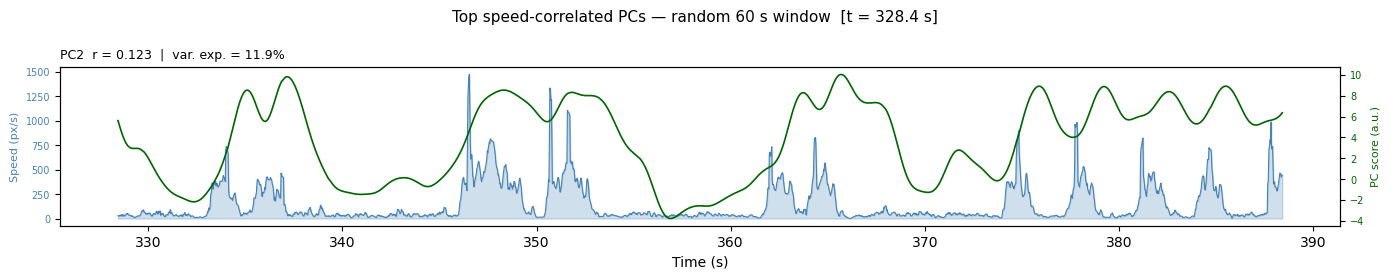

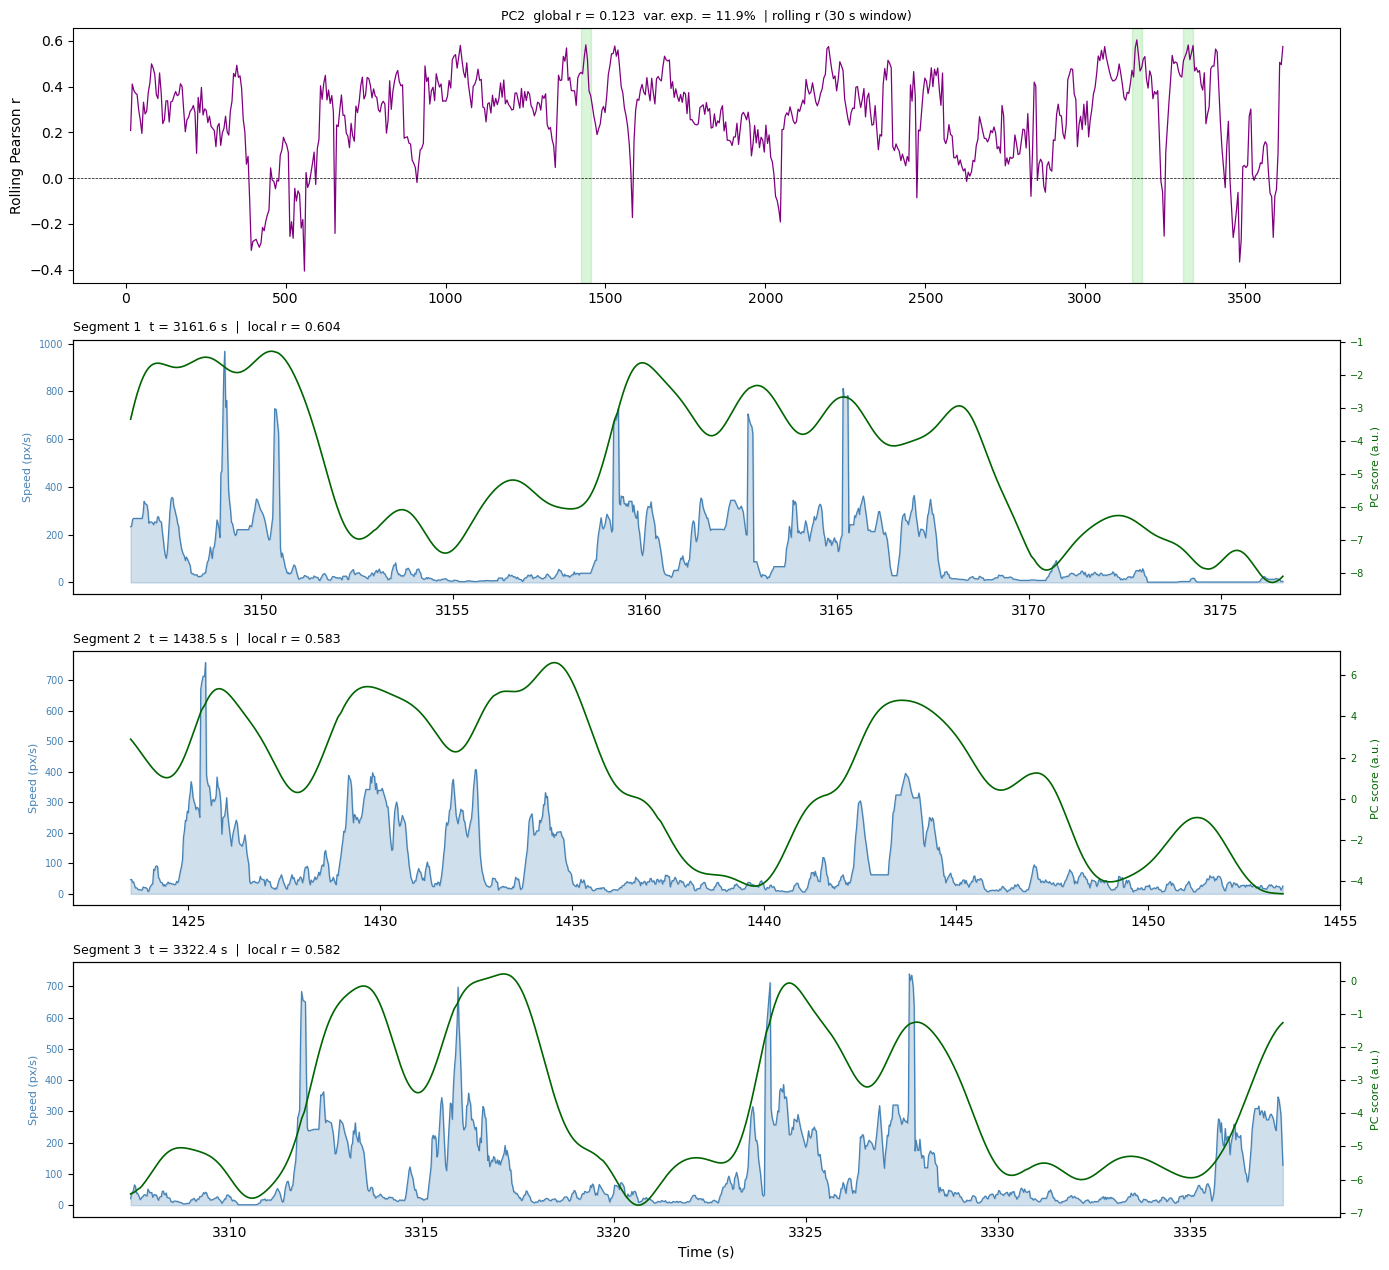

In [31]:
PC_CORR_THRESHOLD = 0.1   # |r| threshold — adjust after seeing the bar chart above
MAX_PC_DETAIL     = 5     # how many PCs to show detail plots for

top_pcs = (pc_corr_df[pc_corr_df['abs_r'] > PC_CORR_THRESHOLD]
           .sort_values('abs_r', ascending=False)
           .head(MAX_PC_DETAIL))

print(f"PCs with |r| > {PC_CORR_THRESHOLD}: {len(top_pcs)}")
display(top_pcs)

# --- random window overview (all top PCs stacked) ---
WINDOW_S_PC = 60.0
t_pc_start  = t_speed_abs[0] + random.uniform(
    0, max(0, (t_speed_abs[-1] - t_speed_abs[0]) - WINDOW_S_PC)
)
t_pc_end    = t_pc_start + WINDOW_S_PC
win_mask_pc = (t_speed_abs >= t_pc_start) & (t_speed_abs <= t_pc_end)
t_win_pc    = t_speed_abs[win_mask_pc]
spd_win_pc  = speed_global[win_mask_pc]

n_pc_panels = len(top_pcs)
if n_pc_panels == 0:
    print("No PCs above threshold — lower PC_CORR_THRESHOLD and re-run.")
else:
    fig, axes = plt.subplots(n_pc_panels, 1,
                             figsize=(14, 2.8 * n_pc_panels),
                             sharex=True)
    if n_pc_panels == 1:
        axes = [axes]

    for ax, (_, prow) in zip(axes, top_pcs.iterrows()):
        k    = int(prow['pc']) - 1
        r_pc = prow['r']
        score_win = pc_scores[win_mask_pc, k]

        ax2 = ax.twinx()
        ax.fill_between(t_win_pc, spd_win_pc, alpha=0.25, color='steelblue')
        ax.plot(t_win_pc, spd_win_pc, color='steelblue', linewidth=0.8)
        ax.set_ylabel('Speed (px/s)', color='steelblue', fontsize=8)
        ax.tick_params(axis='y', labelcolor='steelblue', labelsize=7)

        ax2.plot(t_win_pc, score_win, color='darkgreen', linewidth=1.2)
        ax2.set_ylabel('PC score (a.u.)', color='darkgreen', fontsize=8)
        ax2.tick_params(axis='y', labelcolor='darkgreen', labelsize=7)

        ax.set_title(
            f"PC{k + 1}  r = {r_pc:.3f}  |  var. exp. = {prow['var_exp']*100:.1f}%",
            fontsize=9, loc='left'
        )

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(
        f"Top speed-correlated PCs — random {int(WINDOW_S_PC)} s window  "
        f"[t = {t_pc_start:.1f} s]",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

    # --- rolling correlation + best segments for each top PC ---
    for _, prow in top_pcs.iterrows():
        k        = int(prow['pc']) - 1
        r_global = prow['r']
        score    = pc_scores[:, k]

        t_cens, r_roll = rolling_corr(score)   # reuse helper from above
        seg_centers    = pick_top_segments(t_cens, r_roll)

        n_segs = len(seg_centers)
        fig, axes = plt.subplots(1 + n_segs, 1,
                                 figsize=(14, 3.2 * (1 + n_segs)))
        if 1 + n_segs == 1:
            axes = [axes]

        ax0 = axes[0]
        ax0.plot(t_cens, r_roll, color='purple', linewidth=0.9)
        ax0.axhline(0, color='black', linewidth=0.5, linestyle='--')
        for tc in seg_centers:
            ax0.axvspan(tc - ROLLING_WINDOW_S / 2, tc + ROLLING_WINDOW_S / 2,
                        alpha=0.18, color='limegreen')
        ax0.set_ylabel('Rolling Pearson r')
        ax0.set_title(
            f"PC{k + 1}  global r = {r_global:.3f}  var. exp. = {prow['var_exp']*100:.1f}%  "
            f"| rolling r ({int(ROLLING_WINDOW_S)} s window)",
            fontsize=9
        )

        for j, tc in enumerate(seg_centers):
            ax  = axes[j + 1]
            t0  = tc - ROLLING_WINDOW_S / 2
            t1  = tc + ROLLING_WINDOW_S / 2
            seg_mask = (t_speed_abs >= t0) & (t_speed_abs <= t1)
            t_seg    = t_speed_abs[seg_mask]
            spd_seg  = spd_filled[seg_mask]
            sc_seg   = score[seg_mask]

            closest = int(np.argmin(np.abs(t_cens - tc)))
            r_local = r_roll[closest]

            ax2 = ax.twinx()
            ax.fill_between(t_seg, spd_seg, alpha=0.25, color='steelblue')
            ax.plot(t_seg, spd_seg, color='steelblue', linewidth=0.9)
            ax.set_ylabel('Speed (px/s)', color='steelblue', fontsize=8)
            ax.tick_params(axis='y', labelcolor='steelblue', labelsize=7)

            ax2.plot(t_seg, sc_seg, color='darkgreen', linewidth=1.2)
            ax2.set_ylabel('PC score (a.u.)', color='darkgreen', fontsize=8)
            ax2.tick_params(axis='y', labelcolor='darkgreen', labelsize=7)

            ax.set_title(
                f"Segment {j + 1}  t = {tc:.1f} s  |  local r = {r_local:.3f}",
                fontsize=9, loc='left'
            )

        axes[-1].set_xlabel('Time (s)')
        plt.tight_layout()
        plt.show()